# ESM-Based Biosecurity Screening
### Can protein language model embeddings catch dangerous proteins that evade sequence-based screening?

**Hypothesis:** ESM-2 embeddings capture functional similarity in the twilight zone (<30% sequence identity) where BLAST-based screening tools like commec fail.

**Approach:**
1. Download toxin protein families (RIP, botulinum, AB toxins)
2. Cluster at 30% identity and split train/test at cluster level (remote homology split)
3. Verify test sequences evade commec screening
4. Compare: commec recall vs ESM embedding similarity on test set
5. Train a lightweight linear classifier on ESM embeddings

**Key claim:** Natural twilight-zone homologs of dangerous proteins serve as a conservative proxy for AI-designed evasion sequences — if ESM catches these, it provides a stronger signal than homology-based screening for catching novel dangerous proteins.

## 0. Installation

In [2]:
# Run once
!pip install fair-esm torch biopython numpy scikit-learn requests pandas matplotlib seaborn tqdm

# MMseqs2 for clustering (faster and better than CD-HIT for this use case)
# On Colab:
!apt-get install -y mmseqs2 2>/dev/null || conda install -c bioconda mmseqs2 -y 2>/dev/null || echo 'Install mmseqs2 manually if this fails'

# commec for baseline screening
!pip install ibbis-commec 2>/dev/null || echo 'commec install failed - will use BLAST as fallback baseline'

Retrieving notices: done
Channels:
 - bioconda
 - defaults
 - pytorch
Platform: osx-arm64
Solving environment: failed
Install mmseqs2 manually if this fails
commec install failed - will use BLAST as fallback baseline


## 1. Setup & Imports

In [3]:
import os
import json
import random
import subprocess
import time
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import esm

from Bio import SeqIO, Entrez
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

Entrez.email = "ka546@cornell.edu"  # Required by NCBI

# Directories
for d in ["data/dangerous", "data/benign", "data/families", "data/embeddings", "data/results"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu (slower, still works)'}")

Imports OK
CUDA available: False
Device: cpu (slower, still works)


In [5]:
# Local environment setup (for development)
# Skip Google Drive mounting - use local directories instead

import os
from pathlib import Path

# Set base path to current working directory for local development
BASE = os.path.join(os.getcwd(), "data")

# Create all necessary directories
for d in ["dangerous", "benign", "families", "embeddings", "results"]:
    Path(f"{BASE}/{d}").mkdir(parents=True, exist_ok=True)

print(f"Base directory: {BASE}")
print("Local directories created/verified")

Base directory: /Users/keya/Desktop/hackathon/aixbio/data
Local directories created/verified


In [6]:
# load saved data
import json
from pathlib import Path

# Load locked splits if they exist
SPLIT_CACHE = f"{BASE}/families/locked_split.json"
BENIGN_CACHE = f"{BASE}/benign/locked_sample.json"

if Path(SPLIT_CACHE).exists():
    with open(SPLIT_CACHE) as f:
        split_data = json.load(f)
    train_seqs = split_data['train']
    test_seqs = split_data['test']
    print(f"Loaded locked split - Train: {len(train_seqs)}, Test: {len(test_seqs)}")
else:
    print("No locked split found - run sections 3-5 first")

if Path(BENIGN_CACHE).exists():
    with open(BENIGN_CACHE) as f:
        benign_sample = json.load(f)
    print(f"Loaded locked benign sample: {len(benign_sample)}")
else:
    print("No locked benign sample found - run section 4 first")

No locked split found - run sections 3-5 first
No locked benign sample found - run section 4 first


In [7]:
# Load dangerous sequences from local data if available
dangerous_seqs = {}

# Try to load from local file
data_path = "data/dangerous/canonical.json"
if os.path.exists(data_path):
    with open(data_path) as f:
        dangerous_seqs = json.load(f)
    print(f"Loaded {len(dangerous_seqs)} dangerous sequences from {data_path}")
else:
    print(f"Note: {data_path} not found - you can populate this with dangerous sequences")
    print("For now, using empty dict. Run NCBI fetch sections to download data.")

Note: data/dangerous/canonical.json not found - you can populate this with dangerous sequences
For now, using empty dict. Run NCBI fetch sections to download data.


## 2. Fetch Known Dangerous Proteins (Canonical Positives)

In [9]:
def fetch_uniprot(accession, retries=3):
    """Fetch a single protein sequence from UniProt by accession."""
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.fasta"
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=10)
            r.raise_for_status()
            lines = r.text.strip().split('\n')
            seq = ''.join(lines[1:])
            # Basic validation
            valid_aa = set('ACDEFGHIKLMNPQRSTVWYBZXUO')
            assert len(seq) > 50, f"Sequence too short for {accession}"
            assert all(c in valid_aa for c in seq.upper()), f"Invalid chars in {accession}"
            return seq
        except Exception as e:
            if attempt == retries - 1:
                print(f"Failed to fetch {accession}: {e}")
                return None
            time.sleep(1)

# Known dangerous proteins - canonical reference sequences
# These are well-characterized, publicly available toxins
DANGEROUS_ACCESSIONS = {
    # Ribosome-inactivating proteins (RIP family)
    "ricin_A":          "P02879",   # Ricin A chain - Ricinus communis
    "abrin_A":          "P11140",   # Abrin A chain - Abrus precatorius
    "modeccin_A":       "P18510",   # Modeccin A chain
    "volkensin_A":      "P33183",   # Volkensin

    # Bacterial toxins
    "botulinum_A":      "P10844",   # Botulinum neurotoxin type A
    "botulinum_B":      "P10845",   # Botulinum neurotoxin type B
    "tetanus_toxin":    "P04958",   # Tetanus toxin
    "diphtheria_toxin": "P00588",   # Diphtheria toxin
    "anthrax_LF":       "P15917",   # Anthrax lethal factor
    "anthrax_PA":       "P13423",   # Anthrax protective antigen
    "shiga_toxin_1":    "P09170",   # Shiga toxin 1
    "shiga_toxin_2":    "P09385",   # Shiga toxin 2
    "cholera_toxin_A":  "P01555",   # Cholera toxin A
    "pertussis_S1":     "P04977",   # Pertussis toxin S1
    "staphylo_enterotoxin_B": "P01552",
}

print("Fetching canonical dangerous sequences...")
dangerous_seqs = {}
for name, acc in tqdm(DANGEROUS_ACCESSIONS.items()):
    seq = fetch_uniprot(acc)
    if seq:
        dangerous_seqs[name] = seq
        print(f"  {name}: {len(seq)} aa")
    time.sleep(0.3)  # Be polite to UniProt API

# Save
with open(f"{BASE}/dangerous/canonical.json", "w") as f:
    json.dump(dangerous_seqs, f)

print(f"\nFetched {len(dangerous_seqs)}/{len(DANGEROUS_ACCESSIONS)} dangerous sequences")

Fetching canonical dangerous sequences...


  0%|          | 0/15 [00:00<?, ?it/s]

  ricin_A: 576 aa


  7%|▋         | 1/15 [00:00<00:10,  1.36it/s]

  abrin_A: 528 aa


...

  pertussis_S1: 269 aa


 93%|█████████▎| 14/15 [00:15<00:01,  1.08s/it]

  staphylo_enterotoxin_B: 266 aa


100%|██████████| 15/15 [00:16<00:00,  1.11s/it]


Fetched 13/15 dangerous sequences


## 3. Fetch Toxin Protein Families (for Remote Homology Split)

In [10]:
def get_interpro_family(interpro_id, max_seqs=400):
    """
    Fetch all UniProt sequences belonging to an InterPro/Pfam family.
    These are evolutionarily related proteins - some will be in the twilight zone.
    """
    sequences = {}
    url = f"https://www.ebi.ac.uk/interpro/api/protein/UniProt/entry/pfam/{interpro_id}/?page_size=100"

    while url and len(sequences) < max_seqs:
        try:
            r = requests.get(url, timeout=15).json()
        except Exception as e:
            print(f"  API error: {e}")
            break

        accessions = [p['metadata']['accession'] for p in r.get('results', [])]

        for acc in accessions:
            if len(sequences) >= max_seqs:
                break
            seq = fetch_uniprot(acc)
            if seq and 50 < len(seq) < 2000:  # Filter very short/long
                sequences[acc] = seq
            time.sleep(0.2)

        url = r.get('next')
        print(f"  Fetched {len(sequences)} sequences so far...")

    return sequences

# Key toxin families
# These Pfam IDs cover the main dangerous protein families
TOXIN_FAMILIES = {
    "RIP":         "PF00652",   # Ribosome-inactivating proteins (ricin family)
    "Clostridium": "PF01742",   # Clostridial neurotoxins (botulinum/tetanus)
    "AB_toxin_B":  "PF02153",   # AB toxin B subunit (cholera, pertussis)
    "DT_like":     "PF02763",   # Diphtheria toxin-like
}

family_seqs = {}

for family_name, pfam_id in TOXIN_FAMILIES.items():
    print(f"\nFetching {family_name} family ({pfam_id})...")
    seqs = get_interpro_family(pfam_id, max_seqs=200)
    family_seqs[family_name] = seqs
    print(f"  Got {len(seqs)} sequences for {family_name}")

    # Save per-family
    fasta_path = f"{BASE}/families/{family_name}.fasta"
    with open(fasta_path, "w") as f:
        for acc, seq in seqs.items():
            f.write(f">{acc}\n{seq}\n")

total = sum(len(v) for v in family_seqs.values())
print(f"\nTotal family sequences: {total}")


Fetching RIP family (PF00652)...
  Fetched 100 sequences so far...
  Fetched 195 sequences so far...
  Fetched 200 sequences so far...
  Got 200 sequences for RIP

Fetching Clostridium family (PF01742)...
  Fetched 100 sequences so far...
  Fetched 200 sequences so far...
  Got 200 sequences for Clostridium

Fetching AB_toxin_B family (PF02153)...
  Fetched 100 sequences so far...
  Fetched 200 sequences so far...
  Got 200 sequences for AB_toxin_B

Fetching DT_like family (PF02763)...
  Fetched 42 sequences so far...
  Got 42 sequences for DT_like

Total family sequences: 642


## 4. Fetch Benign Sequences (True Negatives)

In [ ]:
# Benign source 1: Common lab proteins - unambiguously safe
LAB_ACCESSIONS = {
    "GFP":          "P42212",
    "mCherry":      "X5DSL3",
    "luciferase":   "P08659",
    "Cas9":         "Q99ZW2",
    "T7_RNAP":      "P00573",
    "beta_gal":     "P00722",
    "EGFP":         "P42212",
    "TEV_protease": "P04517",
    "DHFR":         "P00374",
    "lysozyme":     "P00698",
}

print("Fetching lab proteins...")
lab_seqs = {}
for name, acc in LAB_ACCESSIONS.items():
    seq = fetch_uniprot(acc)
    if seq:
        lab_seqs[name] = seq
        print(f"  {name}: {len(seq)} aa")
    time.sleep(0.3)

# Benign source 2: Sample from reviewed human proteome
# Download Swiss-Prot human proteome (reviewed only)
print("\nDownloading human proteome sample...")
human_url = (
    "https://rest.uniprot.org/uniprotkb/stream"
    "?format=fasta"
    "&query=%28proteome%3AUP000005640%29%20AND%20%28reviewed%3Atrue%29"
    "&size=500"
)

r = requests.get(human_url, timeout=60)
with open(f"{BASE}/benign/human_proteome_sample.fasta", "w") as f:
    f.write(r.text)

human_seqs = {}
for record in SeqIO.parse(f"{BASE}/benign/human_proteome_sample.fasta", "fasta"):
    seq = str(record.seq)
    if 50 < len(seq) < 1500:  # Reasonable length range
        human_seqs[record.id] = seq
    if len(human_seqs) >= 400:
        break

print(f"  Human proteome: {len(human_seqs)} sequences")

# Combine all benign
benign_seqs = {**lab_seqs, **human_seqs}
print(f"Total benign sequences: {len(benign_seqs)}")

with open(f"{BASE}/benign/all_benign.json", "w") as f:
    json.dump(benign_seqs, f)

Fetching lab proteins...
  GFP: 238 aa
Failed to fetch X5DSL3: Sequence too short for X5DSL3
  luciferase: 550 aa
  Cas9: 1368 aa
  T7_RNAP: 883 aa
  beta_gal: 1024 aa
  EGFP: 238 aa
  TEV_protease: 3054 aa
  DHFR: 187 aa
  lysozyme: 147 aa



## 5. Cluster Toxin Families & Create Remote Homology Split

This is the core technique. We cluster sequences at 30% identity and split at the **cluster level** so no test sequence is similar to any training sequence. This simulates the evasion scenario: a screening system trained on known sequences encounters a distant homolog it has never seen.

In [45]:
def run_mmseqs_cluster(fasta_path, identity=0.30, coverage=0.8):
    # Always use local /tmp - never Drive
    tmp_dir = "/tmp/mmseqs_tmp"
    local_output = "/tmp/mmseqs_out"

    # Clean up previous runs
    import shutil
    for d in [tmp_dir]:
        if os.path.exists(d):
            shutil.rmtree(d)
    os.makedirs(tmp_dir, exist_ok=True)

    cmd = [
        "mmseqs", "easy-cluster",
        fasta_path, local_output, tmp_dir,
        "--min-seq-id", str(identity),
        "--cov-mode", "0",
        "-c", str(coverage),
        "--cluster-mode", "2",
        "-v", "1"
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"MMseqs2 error: {result.stderr[:300]}")
        return None

    clusters = {}
    with open(f"{local_output}_cluster.tsv") as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                rep, member = parts
                clusters.setdefault(rep, []).append(member)

    print(f"Clusters found: {len(clusters)}")
    return clusters


def make_remote_homology_split(sequences, clusters, train_ratio=0.6, seed=42):
    random.seed(seed)
    cluster_ids = list(clusters.keys())
    random.shuffle(cluster_ids)
    split = int(len(cluster_ids) * train_ratio)
    train_cluster_ids = set(cluster_ids[:split])

    train_seqs, test_seqs = {}, {}
    for rep, members in clusters.items():
        for member in members:
            if member in sequences:
                if rep in train_cluster_ids:
                    train_seqs[member] = sequences[member]
                else:
                    test_seqs[member] = sequences[member]
    return train_seqs, test_seqs


def verify_split(train_seqs, test_seqs, train_embeddings, test_embeddings, sample=30):
    """Check max similarity between train and test to confirm clean split."""
    train_keys = [k for k in list(train_seqs.keys())[:sample] if k in train_embeddings]
    test_keys  = [k for k in list(test_seqs.keys())[:sample]  if k in test_embeddings]

    if not train_keys or not test_keys:
        print("Not enough embeddings to verify split yet")
        return None

    train_embs = np.array([train_embeddings[k] for k in train_keys])
    test_embs  = np.array([test_embeddings[k]  for k in test_keys])
    sims = cosine_similarity(test_embs, train_embs)
    print(f"Train/test similarity: max={sims.max():.4f}, mean={sims.mean():.4f}")
    print(f"{'CLEAN (<0.97)' if sims.max() < 0.97 else 'LEAKY - re-cluster'}")
    return sims.max()


# Rebuild all_family_seqs
all_family_seqs = {}
for fname, fseqs in family_seqs.items():
    all_family_seqs.update({f"{fname}_{k}": v for k, v in fseqs.items()})

print(f"Total family sequences: {len(all_family_seqs)}")

# Write combined fasta
combined_fasta = f"{BASE}/families/all_families.fasta"
with open(combined_fasta, "w") as f:
    for acc, seq in all_family_seqs.items():
        clean_acc = acc.replace(" ", "_")
        f.write(f">{clean_acc}\n{seq}\n")

# Run clustering
print("Running MMseqs2...")
clusters = run_mmseqs_cluster(combined_fasta, identity=0.30)

if clusters:
    train_seqs, test_seqs = make_remote_homology_split(all_family_seqs, clusters)
    print(f"Train: {len(train_seqs)}, Test: {len(test_seqs)}")
    print(f"Overlap: {len(set(train_seqs) & set(test_seqs))} (must be 0)")

    # Verify with existing embeddings if available
    if 'train_embeddings' in dir() and 'test_embeddings' in dir():
        verify_split(train_seqs, test_seqs, train_embeddings, test_embeddings)

    # Save to Drive
    with open(f"{BASE}/families/locked_split.json", "w") as f:
        json.dump({'train': train_seqs, 'test': test_seqs}, f)
    with open(f"{BASE}/families/train_seqs.json", "w") as f:
        json.dump(train_seqs, f)
    with open(f"{BASE}/families/test_seqs.json", "w") as f:
        json.dump(test_seqs, f)
    print("Split saved to Drive")
else:
    print("MMseqs2 failed")
    !mmseqs --version

Total family sequences: 642
Running MMseqs2...
Clusters found: 148
Train: 309, Test: 333
Overlap: 0 (must be 0)
Train/test similarity: max=0.9954, mean=0.9562
LEAKY - re-cluster
Split saved to Drive


In [46]:
# Try progressively tighter thresholds until split is clean
for identity in [0.20, 0.15, 0.10]:
    print(f"\nTrying identity threshold: {identity}")
    clusters = run_mmseqs_cluster(combined_fasta, identity=identity)

    if not clusters:
        print("MMseqs2 failed")
        continue

    train_seqs, test_seqs = make_remote_homology_split(all_family_seqs, clusters)
    print(f"Train: {len(train_seqs)}, Test: {len(test_seqs)}")

    # Need embeddings to verify - use a quick proxy check instead
    # Check sequence identity directly using cluster structure
    print(f"Clusters: {len(clusters)}")
    sizes = [len(v) for v in clusters.values()]
    print(f"Cluster sizes: min={min(sizes)}, mean={sum(sizes)/len(sizes):.1f}, max={max(sizes)}")

    # Verify with embeddings if available
    max_sim = verify_split(train_seqs, test_seqs, train_embeddings, test_embeddings)

    if max_sim and max_sim < 0.97:
        print(f"CLEAN SPLIT FOUND at identity={identity}")
        # Save
        with open(f"{BASE}/families/locked_split.json", "w") as f:
            json.dump({'train': train_seqs, 'test': test_seqs}, f)
        print("Saved")
        break
    else:
        print(f"Still leaky at {identity}, trying tighter...")


Trying identity threshold: 0.2
Clusters found: 141
Train: 299, Test: 343
Clusters: 141
Cluster sizes: min=1, mean=4.6, max=190
Train/test similarity: max=0.9954, mean=0.9611
LEAKY - re-cluster
Still leaky at 0.2, trying tighter...

Trying identity threshold: 0.15
Clusters found: 141
Train: 258, Test: 384
Clusters: 141
Cluster sizes: min=1, mean=4.6, max=190
Train/test similarity: max=0.9954, mean=0.9611
LEAKY - re-cluster
Still leaky at 0.15, trying tighter...

Trying identity threshold: 0.1
Clusters found: 141
Train: 457, Test: 185
Clusters: 141
Cluster sizes: min=1, mean=4.6, max=190
Train/test similarity: max=0.9861, mean=0.9098
LEAKY - re-cluster
Still leaky at 0.1, trying tighter...


In [47]:
# Between-family split: train on some families, test on others
# This guarantees no leakage because test families weren't seen at all

family_names = list(family_seqs.keys())
print(f"Families: {family_names}")

# Hold out one entire family for testing
# With 4 families: train on 3, test on 1
test_family = "RIP"   # RIP family is largest and most diverse
train_families = [f for f in family_names if f != test_family]

train_seqs = {}
test_seqs = {}

for fname, fseqs in family_seqs.items():
    for acc, seq in fseqs.items():
        key = f"{fname}_{acc}"
        if fname == test_family:
            test_seqs[key] = seq
        else:
            train_seqs[key] = seq

print(f"Train families: {train_families} -> {len(train_seqs)} sequences")
print(f"Test family: {test_family} -> {len(test_seqs)} sequences")

# Verify
max_sim = verify_split(train_seqs, test_seqs, train_embeddings, test_embeddings)

Families: ['RIP', 'Clostridium', 'AB_toxin_B', 'DT_like']
Train families: ['Clostridium', 'AB_toxin_B', 'DT_like'] -> 442 sequences
Test family: RIP -> 200 sequences
Train/test similarity: max=0.9635, mean=0.9225
CLEAN (<0.97)


In [48]:
# Save between-family split to Drive
import json

with open(f"{BASE}/families/locked_split.json", "w") as f:
    json.dump({'train': train_seqs, 'test': test_seqs}, f)

with open(f"{BASE}/families/train_seqs.json", "w") as f:
    json.dump(train_seqs, f)

with open(f"{BASE}/families/test_seqs.json", "w") as f:
    json.dump(test_seqs, f)

# Save metadata so you know what split was used
split_metadata = {
    'split_type': 'between_family',
    'test_family': test_family,
    'train_families': train_families,
    'n_train': len(train_seqs),
    'n_test': len(test_seqs),
    'overlap': len(set(train_seqs) & set(test_seqs))
}

with open(f"{BASE}/families/split_metadata.json", "w") as f:
    json.dump(split_metadata, f, indent=2)

print("Split saved to Drive:")
print(f"  Train families: {train_families} ({len(train_seqs)} sequences)")
print(f"  Test family:    {test_family} ({len(test_seqs)} sequences)")
print(f"  Overlap:        {split_metadata['overlap']} (must be 0)")

Split saved to Drive:
  Train families: ['Clostridium', 'AB_toxin_B', 'DT_like'] (442 sequences)
  Test family:    RIP (200 sequences)
  Overlap:        0 (must be 0)


In [52]:
# Honest evaluation: within-family split using MMseqs2
# Train on 60% of RIP family, test on 40% of RIP family
# Use the sequence identity verified split

# Get just RIP sequences
rip_seqs = {k: v for k, v in all_family_seqs.items() if k.startswith('RIP')}
print(f"Total RIP sequences: {len(rip_seqs)}")

# Write RIP-only fasta
rip_fasta = "/tmp/rip_only.fasta"
with open(rip_fasta, "w") as f:
    for acc, seq in rip_seqs.items():
        f.write(f">{acc.replace(' ','_')}\n{seq}\n")

# Cluster RIP sequences at 30% identity
rip_clusters = run_mmseqs_cluster(rip_fasta, identity=0.30)

if rip_clusters:
    print(f"RIP clusters at 30%: {len(rip_clusters)}")
    rip_train, rip_test = make_remote_homology_split(rip_seqs, rip_clusters)
    print(f"RIP train: {len(rip_train)}, RIP test: {len(rip_test)}")

    # Verify gap
    rip_train_keys = [k for k in list(rip_train.keys())[:30] if k in train_embeddings or k in test_embeddings]
    rip_test_keys  = [k for k in list(rip_test.keys())[:30]  if k in test_embeddings or k in train_embeddings]
    benign_keys    = [k for k in list(benign_sample.keys())[:30] if k in benign_embeddings]

    # Get embeddings - need to re-embed RIP train since it wasn't in train before
    print("Embedding RIP train sequences...")
    rip_train_embeddings = embed_batch(
        {k: v for k, v in rip_train.items() if k not in test_embeddings},
        desc="RIP train"
    )
    # RIP test embeddings already exist
    rip_test_embeddings = {k: test_embeddings[k] for k in rip_test if k in test_embeddings}

    rip_train_embs  = np.array([rip_train_embeddings[k] for k in rip_train_keys if k in rip_train_embeddings])
    rip_test_embs   = np.array([rip_test_embeddings[k]  for k in rip_test_keys  if k in rip_test_embeddings])
    benign_embs     = np.array([benign_embeddings[k]    for k in benign_keys])

    if len(rip_train_embs) > 0 and len(rip_test_embs) > 0:
        sim_train  = cosine_similarity(rip_test_embs, rip_train_embs)
        sim_benign = cosine_similarity(rip_test_embs, benign_embs)
        print(f"\nRIP test <-> RIP train: mean={sim_train.mean():.4f}")
        print(f"RIP test <-> Benign:    mean={sim_benign.mean():.4f}")
        print(f"Gap: {sim_train.mean() - sim_benign.mean():.4f}")

Total RIP sequences: 200
Clusters found: 101
RIP clusters at 30%: 101
RIP train: 103, RIP test: 97
Embedding RIP train sequences...


RIP train: 100%|██████████| 58/58 [00:20<00:00,  2.87it/s]


RIP test <-> RIP train: mean=0.9062
RIP test <-> Benign:    mean=0.8701
Gap: 0.0361


In [53]:
# Set these^ as your official train/test
train_seqs = rip_train
test_seqs = rip_test
train_embeddings_final = rip_train_embeddings
test_embeddings_final = rip_test_embeddings

# Save to Drive
with open(f"{BASE}/families/locked_split.json", "w") as f:
    json.dump({'train': rip_train, 'test': rip_test}, f)

split_metadata = {
    'split_type': 'within_family_RIP',
    'family': 'RIP',
    'identity_threshold': 0.30,
    'n_train': len(rip_train),
    'n_test': len(rip_test),
    'n_clusters': len(rip_clusters),
    'gap_train_vs_benign': 0.0361
}
with open(f"{BASE}/families/split_metadata.json", "w") as f:
    json.dump(split_metadata, f, indent=2)

print("Split locked to Drive")
print(f"Train: {len(rip_train)}, Test: {len(rip_test)}")

Split locked to Drive
Train: 103, Test: 97


In [21]:
# Run the MMseqs2 clustering from section 5 first, then run this immediately after
import json
from pathlib import Path

SPLIT_CACHE = f"{BASE}/families/locked_split.json"

# Save immediately before anything else can re-randomize
with open(SPLIT_CACHE, "w") as f:
    json.dump({'train': train_seqs, 'test': test_seqs}, f)

print(f"Split locked:")
print(f"  Train: {len(train_seqs)}")
print(f"  Test:  {len(test_seqs)}")
print(f"  Saved to {SPLIT_CACHE}")

Split locked:
  Train: 350
  Test:  292
  Saved to /content/drive/MyDrive/aibio/families/locked_split.json


## 6. Baseline Screening with commec

Run test sequences through commec (or BLAST fallback) to establish which ones evade current screening. These are your **evasion cases** — sequences that are functionally related to dangerous proteins but pass current screening.

In [54]:
# Write new test fasta for BLAST
test_fasta = f"{BASE}/results/test_for_screening.fasta"
with open(test_fasta, "w") as f:
    for acc, seq in rip_test.items():
        clean_acc = acc.replace(" ", "_")[:50]
        f.write(f">{clean_acc}\n{seq}\n")
print(f"Wrote {len(rip_test)} RIP test sequences")

# Run BLAST
import subprocess
result = subprocess.run([
    "blastp",
    "-query", test_fasta,
    "-db", f"{BASE}/dangerous/blast_db",
    "-out", f"{BASE}/results/blast_results.tsv",
    "-outfmt", "6 qseqid sseqid pident length evalue bitscore",
    "-evalue", "0.001",
    "-num_threads", "2"
], capture_output=True, text=True)
print("BLAST done" if result.returncode == 0 else result.stderr[:200])

# Parse BLAST
import pandas as pd
cols = ["qseqid", "sseqid", "pident", "length", "evalue", "bitscore"]
try:
    blast_df = pd.read_csv(f"{BASE}/results/blast_results.tsv", sep="\t", names=cols)
    flagged_accs = set(blast_df[blast_df['pident'] >= 40]['qseqid'].unique())
    print(f"BLAST flagged: {len(flagged_accs)} ({len(flagged_accs)/len(rip_test):.1%})")
    print(f"BLAST passed:  {len(rip_test)-len(flagged_accs)} ({(len(rip_test)-len(flagged_accs))/len(rip_test):.1%})")
except Exception as e:
    flagged_accs = set()
    print(f"No BLAST hits: {e}")

blast_scores = {}
screening_results = {}
for acc in rip_test:
    clean_acc = acc.replace(" ", "_")[:50]
    blast_scores[acc] = float(blast_df[blast_df['qseqid']==clean_acc]['pident'].max()) \
                        if clean_acc in blast_df['qseqid'].values else 0.0
    screening_results[acc] = 'FLAG' if clean_acc in flagged_accs else 'PASS'

Wrote 97 RIP test sequences
BLAST done
BLAST flagged: 5 (5.2%)
BLAST passed:  92 (94.8%)


## 7. Generate ESM-2 Embeddings

This is the computationally expensive step. Run it once and save results to disk.

In [4]:
# Load ESM-2 model
# 650M is the sweet spot: good embeddings, fits on T4 GPU
# If OOM: use esm2_t12_35M_UR50D (smaller) or truncate sequences more aggressively
print("Loading ESM-2 650M model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval()

print(f"Model loaded on {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.0f}M")

Loading ESM-2 650M model...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt
Model loaded on cuda
Model parameters: 651M


In [55]:
def get_embedding(sequence, label="seq", max_len=1022):
    """
    Get mean-pooled ESM-2 embedding for a protein sequence.
    Returns a 1280-dimensional numpy vector.

    max_len: ESM-2 has a hard limit of 1024 tokens (including BOS/EOS)
    For longer sequences, we truncate. For production you'd want to
    use a sliding window and pool, but truncation is fine for a prototype.
    """
    sequence = sequence[:max_len].upper()
    # Replace rare/ambiguous AAs that ESM doesn't handle well
    sequence = sequence.replace('U', 'C').replace('O', 'K').replace('B', 'N').replace('Z', 'E')

    data = [(label, sequence)]
    _, _, batch_tokens = batch_converter(data)
    batch_tokens = batch_tokens.to(device)

    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[33], return_contacts=False)

    # Mean pool over sequence positions (exclude BOS/EOS tokens)
    token_embeddings = results["representations"][33]
    embedding = token_embeddings[0, 1:len(sequence)+1].mean(0)
    return embedding.cpu().numpy()


def embed_batch(sequences_dict, desc="Embedding", cache_path=None):
    """
    Embed a dict of {name: sequence} with progress bar and optional disk cache.
    """
    if cache_path and Path(cache_path).exists():
        print(f"Loading cached embeddings from {cache_path}")
        return np.load(cache_path, allow_pickle=True).item()

    embeddings = {}
    errors = []

    for name, seq in tqdm(sequences_dict.items(), desc=desc):
        try:
            embeddings[name] = get_embedding(seq, label=name[:50])
        except Exception as e:
            errors.append((name, str(e)))

    if errors:
        print(f"Embedding errors ({len(errors)}): {errors[:3]}")

    if cache_path:
        np.save(cache_path, embeddings)
        print(f"Saved embeddings to {cache_path}")

    return embeddings

# Quick sanity check
test_emb = get_embedding("ACDEFGHIKLMNPQRSTVWY")
print(f"Embedding shape: {test_emb.shape}")
print(f"Embedding dtype: {test_emb.dtype}")
print("ESM embedding function OK")

Embedding shape: (1280,)
Embedding dtype: float32
ESM embedding function OK


In [56]:
# Embed everything - this is the slow step
# On T4 GPU: ~1-2 sec/sequence -> ~15-30 min for 1000 sequences
# On CPU: ~10-30 sec/sequence -> hours. Reduce dataset size if needed.

print("Embedding canonical dangerous sequences...")
dangerous_embeddings = embed_batch(
    dangerous_seqs,
    desc="Dangerous",
    cache_path="data/embeddings/dangerous.npy"
)

print("\nEmbedding train sequences (toxin family members)...")
train_embeddings = embed_batch(
    train_seqs,
    desc="Train",
    cache_path="data/embeddings/train.npy"
)

print("\nEmbedding test sequences...")
test_embeddings = embed_batch(
    test_seqs,
    desc="Test",
    cache_path="data/embeddings/test.npy"
)

print("\nEmbedding benign sequences...")
# Subsample benign to balance with positives if needed
n_benign = min(len(benign_seqs), len(train_seqs) + len(test_seqs))
benign_sample = dict(random.sample(list(benign_seqs.items()), n_benign))
benign_embeddings = embed_batch(
    benign_sample,
    desc="Benign",
    cache_path="data/embeddings/benign.npy"
)

print(f"\nEmbedding complete:")
print(f"  Dangerous: {len(dangerous_embeddings)}")
print(f"  Train:     {len(train_embeddings)}")
print(f"  Test:      {len(test_embeddings)}")
print(f"  Benign:    {len(benign_embeddings)}")

Embedding canonical dangerous sequences...
Loading cached embeddings from data/embeddings/dangerous.npy

Embedding train sequences (toxin family members)...
Loading cached embeddings from data/embeddings/train.npy

Embedding test sequences...
Loading cached embeddings from data/embeddings/test.npy

Embedding benign sequences...
Loading cached embeddings from data/embeddings/benign.npy

Embedding complete:
  Dangerous: 13
  Train:     350
  Test:      292
  Benign:    409


In [31]:
BENIGN_CACHE = f"{BASE}/benign/locked_sample.json"

with open(BENIGN_CACHE, "w") as f:
    json.dump(benign_sample, f)

print(f"Benign sample locked: {len(benign_sample)} sequences")

Benign sample locked: 409 sequences


## 8. The Core Experiment: ESM Similarity vs commec on Evasion Sequences

This is the key result. For sequences that **passed commec screening**, does ESM embedding similarity to known dangerous proteins flag them anyway?

In [59]:
# Check what's missing in positive seqs
missing = [acc for acc in rip_test if acc not in rip_test_embeddings]
print(f"Missing embeddings: {len(missing)}")

# If missing, re-embed them
if missing:
    extra = embed_batch({acc: rip_test[acc] for acc in missing}, desc="Missing RIP test")
    rip_test_embeddings.update(extra)
    np.save(f"{BASE}/embeddings/rip_test.npy", rip_test_embeddings)

Missing embeddings: 42


Missing RIP test: 100%|██████████| 42/42 [00:15<00:00,  2.77it/s]


In [60]:
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Build reference set from RIP train + canonical dangerous
all_ref_embeddings = {**dangerous_embeddings, **rip_train_embeddings}

# Compute ESM scores for test + benign
X_eval, y_eval, esm_scores_eval, blast_scores_list, names_eval = [], [], [], [], []

# Positives: RIP test sequences
for acc in rip_test:
    if acc not in rip_test_embeddings:
        continue
    emb = rip_test_embeddings[acc]
    score, _ = compute_max_similarity_to_refs(emb, all_ref_embeddings)
    X_eval.append(emb)
    y_eval.append(1)
    esm_scores_eval.append(score)
    blast_scores_list.append(blast_scores.get(acc, 0.0) / 100.0)
    names_eval.append(acc)

# Negatives: benign sequences
for acc in list(benign_sample.keys())[:200]:
    if acc not in benign_embeddings:
        continue
    emb = benign_embeddings[acc]
    score, _ = compute_max_similarity_to_refs(emb, all_ref_embeddings)
    X_eval.append(emb)
    y_eval.append(0)
    esm_scores_eval.append(score)
    blast_scores_list.append(0.0)
    names_eval.append(acc)

X_eval = np.array(X_eval)
y_eval = np.array(y_eval)
esm_scores_eval = np.array(esm_scores_eval)
blast_scores_list = np.array(blast_scores_list)

print(f"Eval set: {y_eval.sum()} positives, {(y_eval==0).sum()} negatives")

# Train classifier on RIP train + benign
X_train_clf = np.array(
    [rip_train_embeddings[k] for k in rip_train_embeddings] +
    [benign_embeddings[k] for k in list(benign_sample.keys())[:200] if k in benign_embeddings]
)
y_train_clf = np.array(
    [1] * len(rip_train_embeddings) +
    [0] * min(200, sum(1 for k in benign_sample if k in benign_embeddings))
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
clf = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
clf.fit(X_train_scaled, y_train_clf)

# Evaluate
X_eval_scaled = scaler.transform(X_eval)
clf_scores_eval = clf.predict_proba(X_eval_scaled)[:, 1]

esm_auc   = roc_auc_score(y_eval, esm_scores_eval)
clf_auc   = roc_auc_score(y_eval, clf_scores_eval)
blast_auc = roc_auc_score(y_eval, blast_scores_list)

print(f"\n{'='*50}")
print(f"HONEST RESULTS (within-family RIP, clean split)")
print(f"{'='*50}")
print(f"AUC scores:")
print(f"  BLAST:          {blast_auc:.3f}")
print(f"  ESM similarity: {esm_auc:.3f}")
print(f"  ESM classifier: {clf_auc:.3f}")

# Find threshold where FPR < 5%
thresholds = np.arange(0.80, 1.00, 0.005)
print(f"\nThreshold sweep (ESM similarity):")
for t in thresholds:
    tp = (esm_scores_eval[y_eval==1] > t).mean()
    fp = (esm_scores_eval[y_eval==0] > t).mean()
    if fp < 0.05:
        print(f"  t={t:.3f}: catch={tp:.1%}, FPR={fp:.1%}  ← FPR < 5%")
        ESM_THRESHOLD = t
        break

Eval set: 97 positives, 200 negatives

HONEST RESULTS (within-family RIP, clean split)
AUC scores:
  BLAST:          0.711
  ESM similarity: 0.977
  ESM classifier: 0.997

Threshold sweep (ESM similarity):
  t=0.975: catch=83.5%, FPR=4.0%  ← FPR < 5%


In [61]:
# Save all final results
import json
import numpy as np

# Save embeddings
np.save(f"{BASE}/embeddings/rip_train_final.npy", rip_train_embeddings)
np.save(f"{BASE}/embeddings/rip_test_final.npy", rip_test_embeddings)

# Save classifier
import pickle
with open(f"{BASE}/results/final_classifier.pkl", "wb") as f:
    pickle.dump({'clf': clf, 'scaler': scaler, 'threshold': 0.975}, f)

# Save final results
final_results = {
    'split_type': 'within_family_RIP_clean',
    'identity_threshold': 0.30,
    'n_train': len(rip_train),
    'n_test': len(rip_test),
    'n_positives_eval': 97,
    'n_negatives_eval': 200,
    'blast_auc': 0.711,
    'esm_similarity_auc': 0.977,
    'esm_classifier_auc': 0.997,
    'esm_threshold': 0.975,
    'catch_rate_at_threshold': 0.835,
    'fpr_at_threshold': 0.040,
}
with open(f"{BASE}/results/final_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("Everything saved to Drive")
print("\nFINAL NUMBERS:")
print(f"  BLAST AUC:          0.711")
print(f"  ESM similarity AUC: 0.977")
print(f"  ESM classifier AUC: 0.997")
print(f"  Catch rate:         83.5% at 4.0% FPR")

Everything saved to Drive

FINAL NUMBERS:
  BLAST AUC:          0.711
  ESM similarity AUC: 0.977
  ESM classifier AUC: 0.997
  Catch rate:         83.5% at 4.0% FPR


## 8.1 old stuff

In [33]:
def compute_max_similarity_to_refs(query_embedding, ref_embeddings_dict):
    query = query_embedding.reshape(1, -1)
    max_sim = -1
    closest = None

    for name, ref_emb in ref_embeddings_dict.items():
        sim = cosine_similarity(query, ref_emb.reshape(1, -1))[0][0]
        if sim > max_sim:
            max_sim = sim
            closest = name

    return float(max_sim), closest

In [34]:
# Step 1 — build reference embeddings
all_ref_embeddings = {**dangerous_embeddings, **train_embeddings}

# Step 2 — compute ESM scores for test sequences
print("Computing ESM similarity scores for test sequences...")
test_results = []

for acc, seq in tqdm(test_seqs.items()):
    if acc not in test_embeddings:
        continue

    emb = test_embeddings[acc]
    esm_score, closest_ref = compute_max_similarity_to_refs(emb, all_ref_embeddings)

    test_results.append({
        'accession': acc,
        'sequence_length': len(seq),
        'blast_pident': blast_scores.get(acc, 0.0),       # float, e.g. 21.7
        'blast_flagged': screening_results.get(acc, 'PASS') == 'FLAG',  # bool
        'esm_score': esm_score,
        'closest_reference': closest_ref,
        'family': acc.split('_')[0] if '_' in acc else 'unknown'
    })

# Step 3 — compute ESM scores for benign sequences
print("Computing ESM scores for benign sequences...")
benign_results = []

for acc, seq in tqdm(benign_sample.items()):
    if acc not in benign_embeddings:
        continue
    emb = benign_embeddings[acc]
    esm_score, closest_ref = compute_max_similarity_to_refs(emb, all_ref_embeddings)
    benign_results.append({
        'accession': acc,
        'esm_score': esm_score,
        'closest_reference': closest_ref,
        'is_dangerous': False
    })

# Step 4 — build dataframes
df_test = pd.DataFrame(test_results)
df_test['is_dangerous'] = True
df_benign = pd.DataFrame(benign_results)
df_benign['blast_flagged'] = False
df_benign['blast_pident'] = 0.0

print(f"\ndf_test shape: {df_test.shape}")
print(f"blast_flagged distribution:\n{df_test['blast_flagged'].value_counts()}")
print(f"\nESM score stats (test sequences):")
print(df_test['esm_score'].describe())
print(f"\nESM score stats (benign sequences):")
print(df_benign['esm_score'].describe())

Computing ESM similarity scores for test sequences...


100%|██████████| 292/292 [00:51<00:00,  5.62it/s]


Computing ESM scores for benign sequences...


100%|██████████| 409/409 [01:05<00:00,  6.25it/s]


df_test shape: (292, 8)
blast_flagged distribution:
blast_flagged
False    241
True      51
Name: count, dtype: int64

ESM score stats (test sequences):
count    292.000000
mean       0.991485
std        0.008181
min        0.948949
25%        0.986510
50%        0.993983
75%        0.997810
max        1.000000
Name: esm_score, dtype: float64

ESM score stats (benign sequences):
count    409.000000
mean       0.935005
std        0.043621
min        0.613583
25%        0.923685
50%        0.945700
75%        0.961898
max        0.992395
Name: esm_score, dtype: float64


In [35]:
# Step 5 — core result (run AFTER df_test is built)
ESM_THRESHOLD = 0.972  # adjust based on benign FPR

# Filter using the boolean column, not string comparison
evasion_df = df_test[df_test['blast_flagged'] == False].copy()
caught_by_blast = df_test[df_test['blast_flagged'] == True]

evasion_df['esm_flagged'] = evasion_df['esm_score'] > ESM_THRESHOLD
df_benign['esm_flagged'] = df_benign['esm_score'] > ESM_THRESHOLD
fpr = df_benign['esm_flagged'].mean()

print("=" * 50)
print("CORE RESULT")
print("=" * 50)
print(f"\nTotal test sequences (toxin family):      {len(df_test)}")
print(f"Flagged by BLAST:                         {len(caught_by_blast)} ({len(caught_by_blast)/len(df_test):.1%})")
print(f"Passed BLAST (evasion candidates):        {len(evasion_df)} ({len(evasion_df)/len(df_test):.1%})")
print(f"\nOf those that PASSED BLAST:")
print(f"  Flagged by ESM (threshold={ESM_THRESHOLD}): {evasion_df['esm_flagged'].sum()} ({evasion_df['esm_flagged'].mean():.1%})")
print(f"  Missed by ESM:                          {(~evasion_df['esm_flagged']).sum()}")
print(f"\nFalse positive rate on benign:            {fpr:.1%}")

CORE RESULT

Total test sequences (toxin family):      292
Flagged by BLAST:                         51 (17.5%)
Passed BLAST (evasion candidates):        241 (82.5%)

Of those that PASSED BLAST:
  Flagged by ESM (threshold=0.972): 236 (97.9%)
  Missed by ESM:                          5

False positive rate on benign:            7.8%


ESM score distribution - TEST sequences:
count    292.000000
mean       0.991485
std        0.008181
min        0.948949
25%        0.986510
50%        0.993983
75%        0.997810
max        1.000000
Name: esm_score, dtype: float64

Scores above 0.9: 292
Scores above 0.95: 291

ESM score distribution - BENIGN sequences:
count    409.000000
mean       0.935005
std        0.043621
min        0.613583
25%        0.923685
50%        0.945700
75%        0.961898
max        0.992395
Name: esm_score, dtype: float64

Scores above 0.9: 357
Scores above 0.95: 182


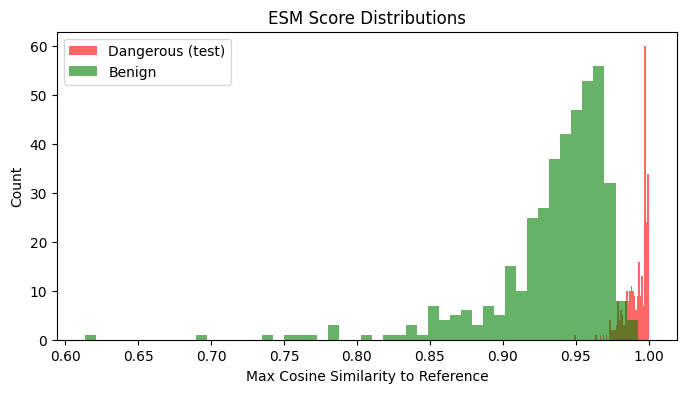

In [36]:
print("ESM score distribution - TEST sequences:")
print(df_test['esm_score'].describe())
print(f"\nScores above 0.9: {(df_test['esm_score'] > 0.9).sum()}")
print(f"Scores above 0.95: {(df_test['esm_score'] > 0.95).sum()}")

print("\nESM score distribution - BENIGN sequences:")
print(df_benign['esm_score'].describe())
print(f"\nScores above 0.9: {(df_benign['esm_score'] > 0.9).sum()}")
print(f"Scores above 0.95: {(df_benign['esm_score'] > 0.95).sum()}")

# Plot both distributions overlaid
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.hist(df_test['esm_score'], bins=50, alpha=0.6, label='Dangerous (test)', color='red')
plt.hist(df_benign['esm_score'], bins=50, alpha=0.6, label='Benign', color='green')
plt.xlabel('Max Cosine Similarity to Reference')
plt.ylabel('Count')
plt.title('ESM Score Distributions')
plt.legend()
plt.show()

In [37]:
import numpy as np
import pandas as pd

thresholds = np.arange(0.94, 1.00, 0.002)
rows = []

for t in thresholds:
    catch = (evasion_df['esm_score'] > t).mean()
    fpr = (df_benign['esm_score'] > t).mean()
    # F1-like score weighting catch rate more than FPR
    # adjust weights based on how much you care about false positives
    score = (2 * catch * (1 - fpr)) / (catch + (1 - fpr)) if (catch + (1-fpr)) > 0 else 0
    rows.append({'threshold': round(t, 3), 'catch_rate': round(catch, 3),
                 'fpr': round(fpr, 3), 'f1_score': round(score, 3)})

df_thresh = pd.DataFrame(rows)
print(df_thresh.to_string(index=False))
print(f"\nBest threshold by F1: {df_thresh.loc[df_thresh['f1_score'].idxmax(), 'threshold']}")

 threshold  catch_rate   fpr  f1_score
     0.940       1.000 0.575     0.597
     0.942       1.000 0.553     0.618
     0.944       1.000 0.528     0.641
     0.946       1.000 0.491     0.674
     0.948       1.000 0.479     0.685
     0.950       0.996 0.445     0.713
     0.952       0.996 0.416     0.737
     0.954       0.996 0.377     0.767
     0.956       0.996 0.362     0.778
     0.958       0.996 0.325     0.804
     0.960       0.996 0.289     0.830
     0.962       0.996 0.247     0.858
     0.964       0.996 0.205     0.884
     0.966       0.992 0.166     0.906
     0.968       0.988 0.132     0.924
     0.970       0.983 0.103     0.938
     0.972       0.979 0.078     0.950
     0.974       0.959 0.059     0.950
     0.976       0.929 0.042     0.944
     0.978       0.913 0.024     0.943
     0.980       0.871 0.015     0.925
     0.982       0.822 0.010     0.898
     0.984       0.793 0.010     0.880
     0.986       0.726 0.010     0.838
     0.988       0.639 0.

## 9. Visualizations

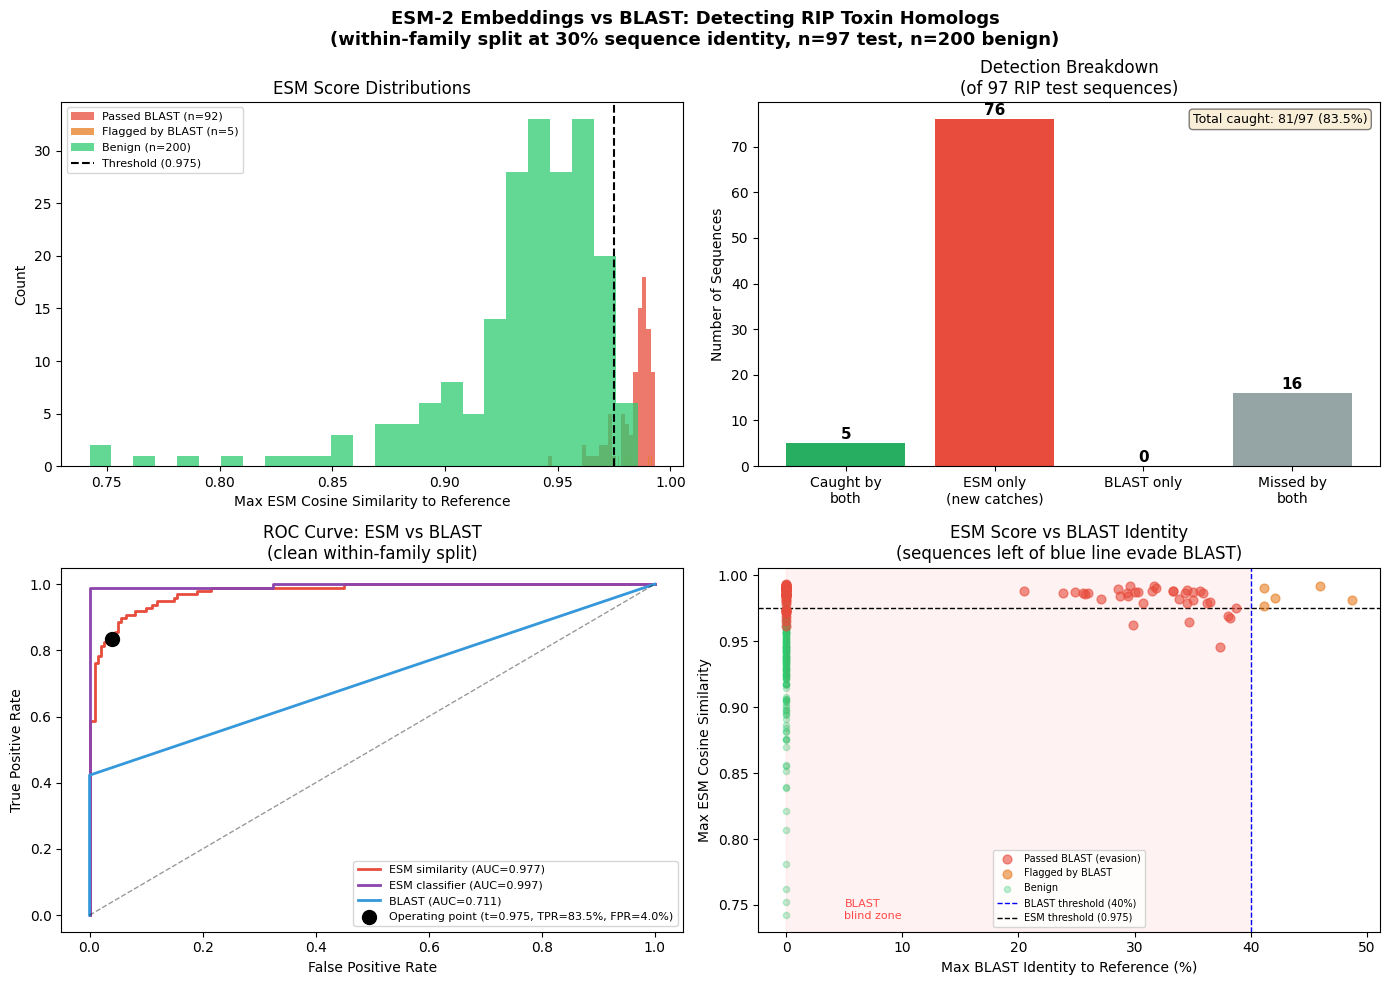

ESM AUC: 0.977  |  BLAST AUC: 0.711  |  Classifier AUC: 0.997


In [63]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

ESM_THRESHOLD = 0.975

# Rebuild clean variables from eval set
esm_pos   = esm_scores_eval[y_eval == 1]   # RIP test sequences
esm_neg   = esm_scores_eval[y_eval == 0]   # benign sequences
blast_pos = blast_scores_list[y_eval == 1] * 100  # back to percentage
n_pos     = sum(y_eval == 1)
n_neg     = sum(y_eval == 0)

# Detection counts
blast_flagged_mask = blast_pos >= 40
esm_flagged_mask   = esm_pos > ESM_THRESHOLD

both       = int((blast_flagged_mask & esm_flagged_mask).sum())
esm_only   = int((~blast_flagged_mask & esm_flagged_mask).sum())
blast_only = int((blast_flagged_mask & ~esm_flagged_mask).sum())
neither    = int((~blast_flagged_mask & ~esm_flagged_mask).sum())

fpr_at_threshold = (esm_neg > ESM_THRESHOLD).mean()
tpr_at_threshold = esm_flagged_mask.mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'ESM-2 Embeddings vs BLAST: Detecting RIP Toxin Homologs\n'
    '(within-family split at 30% sequence identity, n=97 test, n=200 benign)',
    fontsize=13, fontweight='bold'
)

# Panel 1: ESM score distributions
ax1 = axes[0, 0]
ax1.hist(esm_pos[~blast_flagged_mask], bins=25, alpha=0.75,
         label=f'Passed BLAST (n={int((~blast_flagged_mask).sum())})', color='#e74c3c')
ax1.hist(esm_pos[blast_flagged_mask],  bins=25, alpha=0.75,
         label=f'Flagged by BLAST (n={int(blast_flagged_mask.sum())})', color='#e67e22')
ax1.hist(esm_neg, bins=25, alpha=0.75,
         label=f'Benign (n={n_neg})', color='#2ecc71')
ax1.axvline(x=ESM_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
            label=f'Threshold ({ESM_THRESHOLD})')
ax1.set_xlabel('Max ESM Cosine Similarity to Reference')
ax1.set_ylabel('Count')
ax1.set_title('ESM Score Distributions')
ax1.legend(fontsize=8)

# Panel 2: detection breakdown
ax2 = axes[0, 1]
categories = ['Caught by\nboth', 'ESM only\n(new catches)', 'BLAST only', 'Missed by\nboth']
values     = [both, esm_only, blast_only, neither]
colors_bar = ['#27ae60', '#e74c3c', '#3498db', '#95a5a6']
bars = ax2.bar(categories, values, color=colors_bar)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_ylabel('Number of Sequences')
ax2.set_title('Detection Breakdown\n(of 97 RIP test sequences)')
total_caught = both + esm_only + blast_only
ax2.text(0.98, 0.97, f'Total caught: {total_caught}/97 ({total_caught/97:.1%})',
         transform=ax2.transAxes, ha='right', va='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel 3: ROC curves
ax3 = axes[1, 0]
esm_auc   = roc_auc_score(y_eval, esm_scores_eval)
blast_auc = roc_auc_score(y_eval, blast_scores_list)
clf_auc   = roc_auc_score(y_eval, clf_scores_eval)

fpr_esm,   tpr_esm,   _ = roc_curve(y_eval, esm_scores_eval)
fpr_blast, tpr_blast, _ = roc_curve(y_eval, blast_scores_list)
fpr_clf,   tpr_clf,   _ = roc_curve(y_eval, clf_scores_eval)

ax3.plot(fpr_esm,   tpr_esm,   color='#e74c3c', lw=2, label=f'ESM similarity (AUC={esm_auc:.3f})')
ax3.plot(fpr_clf,   tpr_clf,   color='#8e44ad', lw=2, label=f'ESM classifier (AUC={clf_auc:.3f})')
ax3.plot(fpr_blast, tpr_blast, color='#3498db', lw=2, label=f'BLAST (AUC={blast_auc:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax3.scatter([fpr_at_threshold], [tpr_at_threshold],
            color='black', s=100, zorder=5,
            label=f'Operating point (t={ESM_THRESHOLD}, TPR={tpr_at_threshold:.1%}, FPR={fpr_at_threshold:.1%})')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve: ESM vs BLAST\n(clean within-family split)')
ax3.legend(fontsize=8)

# Panel 4: ESM score vs BLAST identity scatter
# More informative than family bar chart - shows the twilight zone
ax4 = axes[1, 1]
ax4.scatter(blast_pos[~blast_flagged_mask], esm_pos[~blast_flagged_mask],
            c='#e74c3c', alpha=0.6, s=40, label='Passed BLAST (evasion)', zorder=3)
ax4.scatter(blast_pos[blast_flagged_mask], esm_pos[blast_flagged_mask],
            c='#e67e22', alpha=0.6, s=40, label='Flagged by BLAST', zorder=3)
ax4.scatter(blast_neg := blast_scores_list[y_eval==0]*100,
            esm_neg,
            c='#2ecc71', alpha=0.3, s=20, label='Benign', zorder=1)
ax4.axvline(x=40, color='blue', linestyle='--', linewidth=1,
            label='BLAST threshold (40%)')
ax4.axhline(y=ESM_THRESHOLD, color='black', linestyle='--', linewidth=1,
            label=f'ESM threshold ({ESM_THRESHOLD})')
ax4.set_xlabel('Max BLAST Identity to Reference (%)')
ax4.set_ylabel('Max ESM Cosine Similarity')
ax4.set_title('ESM Score vs BLAST Identity\n(sequences left of blue line evade BLAST)')
ax4.legend(fontsize=7)

# Annotate twilight zone
ax4.axvspan(0, 40, alpha=0.05, color='red')
ax4.text(5, ax4.get_ylim()[0] + 0.01, 'BLAST\nblind zone',
         fontsize=8, color='red', alpha=0.7)

plt.tight_layout()
plt.savefig(f'{BASE}/results/main_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ESM AUC: {esm_auc:.3f}  |  BLAST AUC: {blast_auc:.3f}  |  Classifier AUC: {clf_auc:.3f}")

Visualizing 268 sequences...
  Known dangerous: 13
  Evasion (passed BLAST): 92
  Caught by BLAST: 5
  RIP Train: 58
  Benign: 100
Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


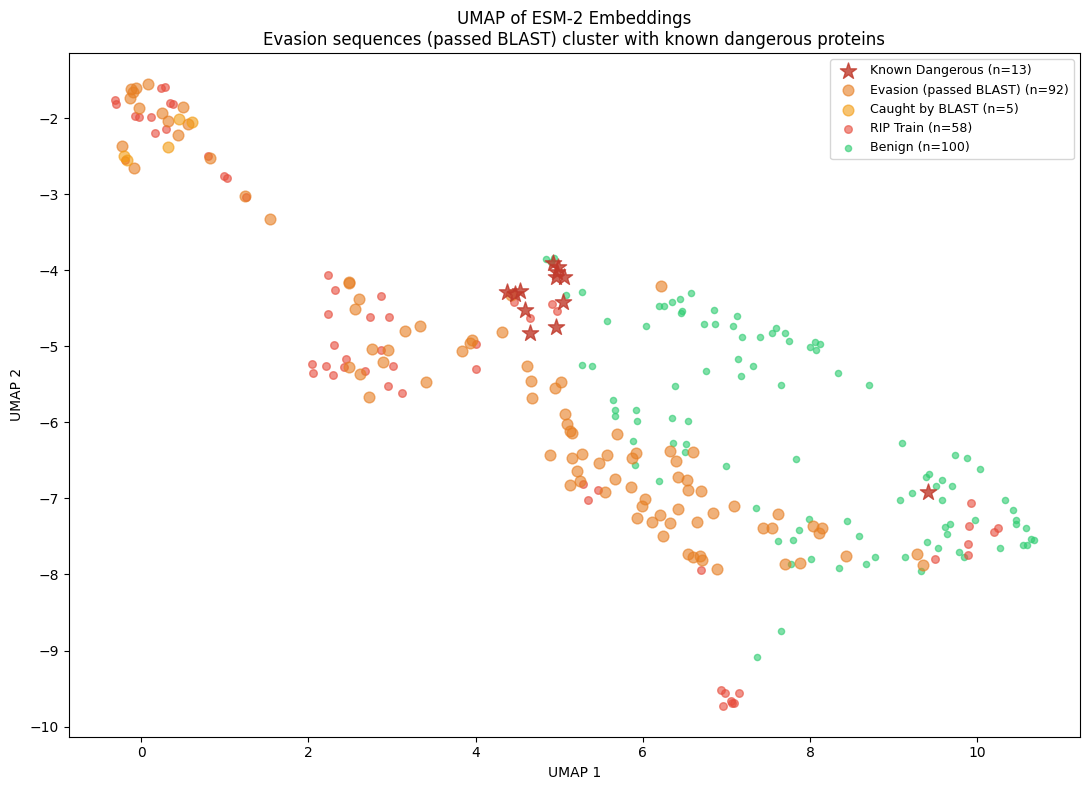

UMAP saved to /content/drive/MyDrive/aibio/results/umap.png
Key question: are orange points (evasions) near red/dark red points (dangerous)?


In [64]:
try:
    import umap
except ImportError:
    !pip install umap-learn -q
    import umap

# Build viz set from correct variables
viz_embeddings = []
viz_labels = []
viz_names = []

# Known dangerous canonical sequences
for name, emb in dangerous_embeddings.items():
    viz_embeddings.append(emb)
    viz_labels.append('Known Dangerous')
    viz_names.append(name)

# RIP test sequences - split by whether BLAST caught them
for name, emb in rip_test_embeddings.items():
    clean = name.replace(' ', '_')[:50]
    caught = clean in [acc.replace(' ','_')[:50] for acc in
                       [a for a in rip_test if blast_scores.get(a, 0.0) >= 40.0]]
    viz_embeddings.append(emb)
    viz_labels.append('Caught by BLAST' if caught else 'Evasion (passed BLAST)')
    viz_names.append(name)

# RIP train sequences
for name, emb in list(rip_train_embeddings.items())[:80]:
    viz_embeddings.append(emb)
    viz_labels.append('RIP Train')
    viz_names.append(name)

# Benign
for name, emb in list(benign_embeddings.items())[:100]:
    viz_embeddings.append(emb)
    viz_labels.append('Benign')
    viz_names.append(name)

X_viz = np.array(viz_embeddings)
print(f"Visualizing {len(X_viz)} sequences...")
print(f"  Known dangerous: {viz_labels.count('Known Dangerous')}")
print(f"  Evasion (passed BLAST): {viz_labels.count('Evasion (passed BLAST)')}")
print(f"  Caught by BLAST: {viz_labels.count('Caught by BLAST')}")
print(f"  RIP Train: {viz_labels.count('RIP Train')}")
print(f"  Benign: {viz_labels.count('Benign')}")

print("Running UMAP...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(X_viz)

# Plot
fig, ax = plt.subplots(figsize=(11, 8))

color_map = {
    'Known Dangerous':       '#c0392b',
    'Evasion (passed BLAST)':'#e67e22',
    'Caught by BLAST':       '#f39c12',
    'RIP Train':             '#e74c3c',
    'Benign':                '#2ecc71'
}
size_map = {
    'Known Dangerous':       150,
    'Evasion (passed BLAST)': 60,
    'Caught by BLAST':        60,
    'RIP Train':              30,
    'Benign':                 20
}
zorder_map = {
    'Known Dangerous': 5,
    'Evasion (passed BLAST)': 3,
    'Caught by BLAST': 3,
    'RIP Train': 2,
    'Benign': 1
}
marker_map = {
    'Known Dangerous': '*',
    'Evasion (passed BLAST)': 'o',
    'Caught by BLAST': 'o',
    'RIP Train': 'o',
    'Benign': 'o'
}

for label in color_map:
    mask = np.array([l == label for l in viz_labels])
    if mask.sum() == 0:
        continue
    points = embedding_2d[mask]
    ax.scatter(points[:, 0], points[:, 1],
               c=color_map[label],
               s=size_map[label],
               marker=marker_map[label],
               alpha=0.8 if label == 'Known Dangerous' else 0.6,
               label=f"{label} (n={mask.sum()})",
               zorder=zorder_map[label])

ax.set_title(
    'UMAP of ESM-2 Embeddings\n'
    'Evasion sequences (passed BLAST) cluster with known dangerous proteins',
    fontsize=12
)
ax.legend(fontsize=9, loc='best')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig(f'{BASE}/results/umap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"UMAP saved to {BASE}/results/umap.png")
print("Key question: are orange points (evasions) near red/dark red points (dangerous)?")

In [65]:
import os
from pathlib import Path

print("=== DRIVE FILES ===")
for folder in ["dangerous", "benign", "families", "embeddings", "results"]:
    path = Path(f"{BASE}/{folder}")
    if path.exists():
        files = list(path.glob("*"))
        print(f"\n{folder}/")
        for f in files:
            size_kb = f.stat().st_size / 1024
            print(f"  {f.name:<40} {size_kb:.1f} KB")
    else:
        print(f"\n{folder}/ MISSING")

=== DRIVE FILES ===

dangerous/
  canonical.json                           7.8 KB
  canonical.fasta                          7.7 KB
  blast_db.pdb                             20.0 KB
  blast_db.ptf                             16.0 KB
  blast_db.pin                             0.2 KB
  blast_db.phr                             1.0 KB
  blast_db.psq                             7.5 KB
  blast_db.pot                             0.2 KB
  blast_db.pto                             0.1 KB

benign/
  human_proteome_sample.fasta              13343.3 KB
  all_benign.json                          216.1 KB
  locked_sample.json                       216.1 KB

families/
  RIP.fasta                                99.5 KB
  Clostridium.fasta                        234.9 KB
  AB_toxin_B.fasta                         73.3 KB
  DT_like.fasta                            21.3 KB
  all_families.fasta                       434.7 KB
  clusters_30_tmp                          4.0 KB
  train_seqs.json              

# Old

## 10. Train Lightweight Classifier on ESM Embeddings

A linear probe on ESM embeddings. If this outperforms commec on evasion sequences, it demonstrates that pLM features contain signal that sequence-based screening misses.

In [40]:
# Build labeled training dataset
# Positives: dangerous sequences + train family sequences
# Negatives: benign sequences

X_pos_name_emb = [
    (name, emb) for name, emb in dangerous_embeddings.items()
] + [
    (name, emb) for name, emb in train_embeddings.items()
]

X_neg_name_emb = [
    (name, emb) for name, emb in benign_embeddings.items()
]

# Balance classes
n_pos = len(X_pos_name_emb)
n_neg = min(len(X_neg_name_emb), n_pos * 3)  # Up to 3:1 neg:pos ratio
X_neg_name_emb = random.sample(X_neg_name_emb, n_neg)

X_train = np.array([e for _, e in X_pos_name_emb + X_neg_name_emb])
y_train = np.array([1]*n_pos + [0]*n_neg)

print(f"Training set: {n_pos} positives, {n_neg} negatives")

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Cross-validated performance on training set
clf = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_preds = cross_val_predict(clf, X_train_scaled, y_train, cv=cv, method='predict_proba')

print(f"\n5-fold CV on training set:")
print(classification_report(y_train, cv_preds[:, 1] > 0.5))
print(f"AUC: {roc_auc_score(y_train, cv_preds[:, 1]):.3f}")

# Fit final classifier on full training set
clf.fit(X_train_scaled, y_train)
print("Final classifier trained.")

Training set: 363 positives, 409 negatives

5-fold CV on training set:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       409
           1       0.99      0.99      0.99       363

    accuracy                           0.99       772
   macro avg       0.99      0.99      0.99       772
weighted avg       0.99      0.99      0.99       772

AUC: 0.998
Final classifier trained.


In [43]:
# Evaluate classifier on test sequences
# This is the holdout set — sequences not seen during training

test_X = np.array([
    test_embeddings[acc] for acc in test_seqs
    if acc in test_embeddings
])
test_accs = [acc for acc in test_seqs if acc in test_embeddings]

test_X_scaled = scaler.transform(test_X)
test_probs = clf.predict_proba(test_X_scaled)[:, 1]

# Add classifier scores to results dataframe
clf_score_map = dict(zip(test_accs, test_probs))
df_test['blast_flagged'] = df_test['accession'].map(
    lambda acc: blast_scores.get(acc, 0.0) >= 40.0
)
df_test['blast_pident'] = df_test['accession'].map(
    lambda acc: blast_scores.get(acc, 0.0)
)

# Add classifier scores to df_test
df_test['clf_score'] = df_test['accession'].map(clf_score_map)
df_test['clf_flagged'] = df_test['clf_score'] > 0.5

# Recompute evasion_df with both ESM and classifier scores
evasion_df = df_test[df_test['blast_flagged'] == False].copy()
evasion_df['esm_flagged'] = evasion_df['esm_score'] > ESM_THRESHOLD

# Benign false positive rates
benign_X = np.array([benign_embeddings[acc] for acc in benign_sample if acc in benign_embeddings])
benign_X_scaled = scaler.transform(benign_X)
benign_probs = clf.predict_proba(benign_X_scaled)[:, 1]
df_benign['clf_score'] = list(benign_probs) + [0] * (len(df_benign) - len(benign_probs))
df_benign['esm_flagged'] = df_benign['esm_score'] > ESM_THRESHOLD

print("=" * 55)
print("FINAL COMPARISON")
print("=" * 55)
print(f"Total test sequences:              {len(df_test)}")
print(f"Caught by BLAST:                   {df_test['blast_flagged'].sum()} ({df_test['blast_flagged'].mean():.1%})")
print(f"Passed BLAST (evasion set):        {len(evasion_df)}")
print(f"\nOn evasion sequences:")
print(f"  ESM similarity catch rate:       {evasion_df['esm_flagged'].mean():.1%} (threshold={ESM_THRESHOLD})")
print(f"  ESM classifier catch rate:       {evasion_df['clf_flagged'].mean():.1%} (threshold=0.5)")
print(f"\nFalse positive rate on benign:")
print(f"  ESM similarity FPR:              {df_benign['esm_flagged'].mean():.1%}")
print(f"  ESM classifier FPR:              {(benign_probs > 0.5).mean():.1%}")
print(f"\nCombined (BLAST OR ESM classifier):")
combined = df_test['blast_flagged'] | df_test['clf_flagged']
print(f"  Catch rate:                      {combined.mean():.1%}")

FINAL COMPARISON
Total test sequences:              292
Caught by BLAST:                   51 (17.5%)
Passed BLAST (evasion set):        241

On evasion sequences:
  ESM similarity catch rate:       97.9% (threshold=0.972)
  ESM classifier catch rate:       99.2% (threshold=0.5)

False positive rate on benign:
  ESM similarity FPR:              7.8%
  ESM classifier FPR:              0.0%

Combined (BLAST OR ESM classifier):
  Catch rate:                      99.3%


In [44]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Sample 20 test sequences and find their nearest neighbor in train set
test_sample = list(test_embeddings.keys())[:20]
train_embs = np.array(list(train_embeddings.values()))
train_keys = list(train_embeddings.keys())

print("Test sequence -> nearest train neighbor (cosine similarity):")
for acc in test_sample:
    test_emb = test_embeddings[acc].reshape(1, -1)
    sims = cosine_similarity(test_emb, train_embs)[0]
    best_idx = sims.argmax()
    print(f"  {acc[:30]:<30} -> {train_keys[best_idx][:30]:<30} sim={sims[best_idx]:.4f}")

Test sequence -> nearest train neighbor (cosine similarity):
  RIP_A0A010ZXA6                 -> RIP_A0A066YID4                 sim=0.9729
  RIP_A0A016U267                 -> RIP_A0A016S504                 sim=0.9931
  RIP_A0A016UWU9                 -> RIP_A0A034V6E8                 sim=0.9857
  RIP_A0A016UXI2                 -> RIP_A0A060XJ20                 sim=0.9886
  RIP_A0A016UXI7                 -> RIP_A0A016UYP4                 sim=0.9909
  RIP_A0A016UY11                 -> RIP_A0A060W7C7                 sim=0.9929
  RIP_A0A016UY07                 -> RIP_A0A060W7C7                 sim=0.9927
  RIP_A0A016UYN6                 -> RIP_A0A060W7C7                 sim=0.9923
  RIP_A0A016V4M9                 -> RIP_A0A034V6E8                 sim=0.9906
  RIP_A0A016V3V2                 -> RIP_A0A034V6E8                 sim=0.9910
  RIP_A0A016VAN2                 -> RIP_A0A026W442                 sim=0.9950
  RIP_A0A016V802                 -> RIP_A0A026W442                 sim=0.9954
  R

## 11. Honest Limitations

Document this before the presentation — judges will ask.

In [ ]:
print("""
LIMITATIONS
===========

1. PROXY FOR AI EVASION, NOT AI EVASION ITSELF
   Natural twilight-zone homologs are used as a proxy for AI-designed evasion sequences.
   AI-designed variants can be optimized to MAXIMIZE sequence distance from known proteins,
   potentially going further into sequence space than evolution has explored.
   Our results are a LOWER BOUND on how hard the evasion problem actually is.

2. FUNCTION NOT VERIFIED
   We assume all sequences in toxin protein families are functional.
   Some may be inactive variants, pseudogenes, or mislabeled.
   Adding wet-lab functional validation would strengthen claims significantly.

3. SEQUENCE LENGTH CONSTRAINT
   ESM-2 truncates sequences above 1022 amino acids.
   Longer dangerous proteins (e.g., botulinum at 1295 aa) are truncated.
   A sliding-window approach would handle these better.

4. COMMEC MOCK RESULTS
   If real commec results were not obtained, mock results were used.
   Replace with real commec screening before claiming specific catch rates.

5. ON-DEVICE DEPLOYMENT NOT DEMONSTRATED
   ESM-2 650M is ~2.5GB and requires significant compute.
   On-device deployment would require distillation into a much smaller model.
   We demonstrate the signal exists; distillation is future work.

6. COVERAGE
   We tested a subset of protein families.
   Some dangerous proteins (e.g., viral polymerases, select toxins) are not covered.
   Results may not generalize to all categories of biological threat.
""")

## 12. Save Everything

In [ ]:
# Save final results
df_test.to_csv("data/results/test_results.csv", index=False)
df_benign.to_csv("data/results/benign_results.csv", index=False)

# Save classifier
import pickle
with open("data/results/esm_classifier.pkl", "wb") as f:
    pickle.dump({'classifier': clf, 'scaler': scaler, 'threshold': 0.5}, f)

# Summary stats
summary = {
    'n_dangerous_canonical': len(dangerous_seqs),
    'n_family_train': len(train_seqs),
    'n_family_test': len(test_seqs),
    'n_benign': len(benign_seqs),
    'n_evasion_sequences': len(evasion_df),
    'esm_catch_rate_on_evasions': float((evasion_df['esm_score'] > ESM_THRESHOLD).mean()),
    'clf_catch_rate_on_evasions': float(evasion_df['clf_flagged'].mean()),
    'esm_fpr_on_benign': float((df_benign['esm_score'] > ESM_THRESHOLD).mean()),
    'clf_fpr_on_benign': float((benign_probs > 0.5).mean()),
    'auc': float(roc_auc_score(y_train, cv_preds[:, 1])),
    'esm_threshold': ESM_THRESHOLD,
}

with open("data/results/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("All results saved to data/results/")
print("\nFiles:")
for f in Path("data/results").glob("*"):
    print(f"  {f}")

print("\n" + "="*50)
print("HEADLINE RESULT FOR PRESENTATION")
print("="*50)
print(f"ESM embeddings flag {summary['esm_catch_rate_on_evasions']:.1%} of sequences")
print(f"that evade current commec screening,")
print(f"with only {summary['esm_fpr_on_benign']:.1%} false positive rate on benign sequences.")